# M2 · Feature Engineering & Leakage — Hands-on Notebook

**Companion to curriculum lesson M2.** This notebook teaches you how to *actually*
handle and normalize **categorical**, **numeric** and **float** features with real,
runnable code — the practical side of M2.3, M2.4 and M2.5.

Every example runs top-to-bottom on a shared synthetic **ads** dataset using only
libraries preinstalled in Google Colab (`pandas`, `numpy`, `scikit-learn`,
`matplotlib`) — **no `pip install` needed**.

**Structure**
- **Basic (10)** — one encoder / scaler per example, with a picture.
- **Easy (5)** — combine steps, transforms, pipelines.
- **Advanced (5)** — leakage-safe target encoding, hashing, embeddings, a full
  fit-on-train pipeline, and an encoder bake-off.

> The golden rule you'll see everywhere: **fit every transform on the training
> split only, then apply it to validation / serving** — otherwise you leak.

## Setup — a small synthetic ads dataset

One row = one ad impression. Columns mix the three feature families:
- **categorical (nominal):** `member_country`, `device`, `campaign_id`
- **categorical (ordinal):** `creative_size` (S < M < L)
- **numeric / float:** `bid`, `spend` (heavy-tailed), `dwell_secs` (has missing values)
- **label:** `clicked` (0/1)

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974"

rng = np.random.default_rng(42)
N = 4000
countries = rng.choice(["US","IN","BR","GB","DE","FR","CA","AU","NG","JP"],
                       size=N, p=[.30,.18,.12,.08,.07,.06,.05,.05,.02,.07])
devices   = rng.choice(["ios","android","web"], size=N, p=[.45,.40,.15])
sizes     = rng.choice(["S","M","L"], size=N, p=[.5,.35,.15])
campaign  = rng.integers(1000, 1000+800, size=N)            # 800 campaigns (high card.)
bid       = np.round(rng.uniform(0.5, 12.0, size=N), 2)
spend     = np.round(rng.exponential(scale=40, size=N), 2)  # heavy-tailed
dwell     = rng.normal(30, 12, size=N).clip(0)
dwell[rng.random(N) < 0.15] = np.nan                        # 15% missing

size_lift = pd.Series({"S":0.0,"M":0.4,"L":0.8})[sizes].to_numpy()
logit = (-3.0 + 0.10*bid + 0.004*spend + size_lift
         + (devices=="ios")*0.3 + (countries=="US")*0.2 + rng.normal(0,0.5,size=N))
clicked = (rng.random(N) < 1/(1+np.exp(-logit))).astype(int)

df = pd.DataFrame(dict(member_country=countries, device=devices, creative_size=sizes,
                       campaign_id=campaign, bid=bid, spend=spend, dwell_secs=dwell,
                       clicked=clicked))

# one honest split we reuse everywhere: fit on train, apply to valid
train, valid = train_test_split(df, test_size=0.25, random_state=0, stratify=df.clicked)
print("rows:", len(df), "| click rate:", round(df.clicked.mean(), 3))
print("train:", len(train), "valid:", len(valid))
df.head()

rows: 4000 | click rate: 0.169
train: 3000 valid: 1000


---
# Basic (10) — one technique per example

Each cell: **what it does → runnable code → a picture.**

## 1 · One-hot encoding — *nominal, low cardinality*

Turn an unordered category into one 0/1 column per value. **Use when** the category
has no order and few values (`device`, `member_country`).
**Gotcha:** columns explode at high cardinality — don't one-hot `campaign_id`.

   device_android  device_ios  device_web
0             1.0         0.0         0.0
1             0.0         1.0         0.0
2             0.0         0.0         1.0
3             0.0         0.0         1.0
4             1.0         0.0         0.0


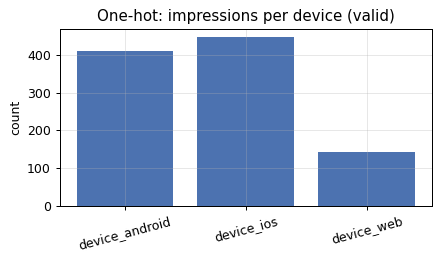

In [2]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe.fit(train[["device"]])                       # fit on train only
enc = ohe.transform(valid[["device"]])
cols = ohe.get_feature_names_out(["device"])
print(pd.DataFrame(enc, columns=cols).head())

plt.figure(figsize=(5,3))
plt.bar(cols, enc.sum(axis=0), color=BLUE)
plt.title("One-hot: impressions per device (valid)"); plt.ylabel("count")
plt.xticks(rotation=15); plt.show()

## 2 · Ordinal encoding — *ordinal, real order*

Map an **ordered** category to integers that preserve order
(`creative_size` S<M<L → 0,1,2). **Use when** order is genuine.
**Gotcha:** never do this to a nominal feature — it invents a fake order (see #3).

mapping: {'S': 0, 'M': 1, 'L': 2}


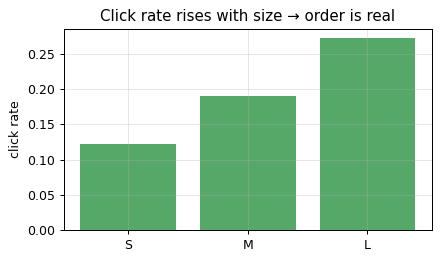

In [3]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[["S","M","L"]])   # declare the true order
_ = oe.fit_transform(train[["creative_size"]])
print("mapping:", dict(zip(["S","M","L"], [0,1,2])))

rate = train.groupby("creative_size").clicked.mean().reindex(["S","M","L"])
plt.figure(figsize=(5,3))
plt.bar(rate.index, rate.values, color=GREEN)
plt.title("Click rate rises with size → order is real"); plt.ylabel("click rate"); plt.show()

## 3 · Label-encoding a *nominal* feature — the fake-order trap

Blindly integer-coding a nominal feature (`device` → 0/1/2) tells a linear model
"web > android > ios", which is meaningless. This is #2 done **wrong**, shown so you
recognize it. **Fix:** one-hot (or hashing / embeddings) for nominal.

fake ordering imposed: {'android': 0, 'ios': 1, 'web': 2}


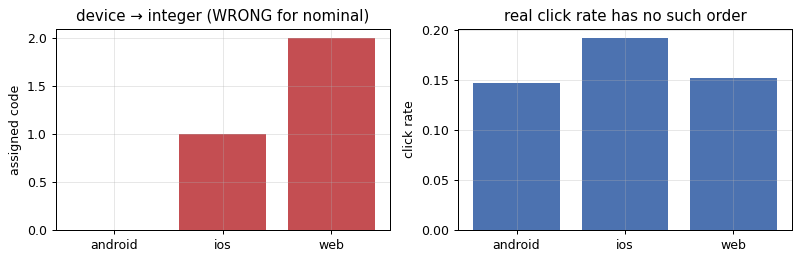

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder().fit(train["device"])
print("fake ordering imposed:", dict(zip(le.classes_, le.transform(le.classes_))))

fig, ax = plt.subplots(1, 2, figsize=(9,3))
ax[0].bar(le.classes_, le.transform(le.classes_), color=RED)
ax[0].set_title("device → integer (WRONG for nominal)"); ax[0].set_ylabel("assigned code")
rate = [train.loc[train.device==c, "clicked"].mean() for c in le.classes_]
ax[1].bar(le.classes_, rate, color=BLUE)
ax[1].set_title("real click rate has no such order"); ax[1].set_ylabel("click rate")
plt.show()

## 4 · Count / frequency encoding — *medium cardinality*

Replace each category with how often it appears: cheap, one column, no explosion.
**Use when** popularity itself is signal (`member_country`).
**Gotcha:** two equally-frequent categories collide to the same value.

US    0.307
IN    0.176
BR    0.117
GB    0.083
JP    0.070
Name: member_country, dtype: float64


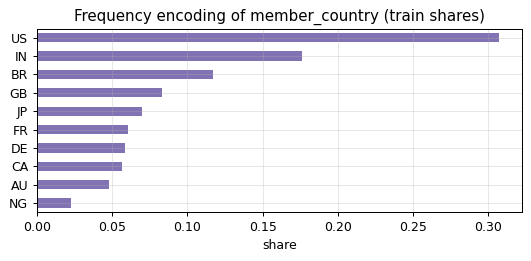

In [5]:
freq = train["member_country"].value_counts(normalize=True)   # learned on train
valid_freq = valid["member_country"].map(freq).fillna(0.0)     # unseen -> 0
print(freq.round(3).head())

plt.figure(figsize=(6,3))
freq.sort_values().plot(kind="barh", color=PURPLE)
plt.title("Frequency encoding of member_country (train shares)"); plt.xlabel("share"); plt.show()

## 5 · Standardization (z-score) — *numeric*

$z=(x-\mu)/\sigma$ using **train** $\mu,\sigma$: mean 0, unit variance.
**Use for** linear / neural models. **Trees don't need it.**
**Gotcha:** fit $\mu,\sigma$ on train only — fitting on all rows leaks.

train mean~0: -0.0  std~1: 1.0


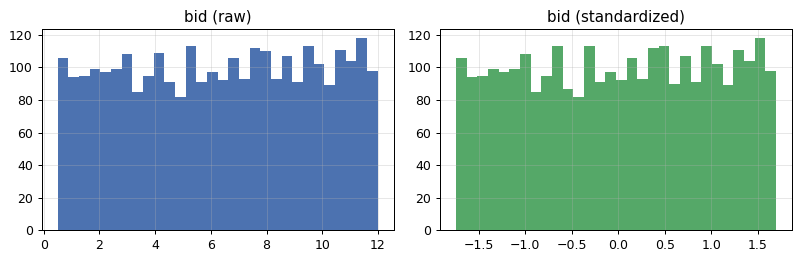

In [6]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler().fit(train[["bid"]])         # mu, sigma from train
z_train = sc.transform(train[["bid"]]).ravel()
print("train mean~0:", round(z_train.mean(),3), " std~1:", round(z_train.std(),3))

fig, ax = plt.subplots(1, 2, figsize=(9,3))
ax[0].hist(train.bid, bins=30, color=BLUE);   ax[0].set_title("bid (raw)")
ax[1].hist(z_train, bins=30, color=GREEN);    ax[1].set_title("bid (standardized)")
plt.show()

## 6 · Min–max scaling — *numeric to [0,1]*

Rescale to a fixed range with train min/max. **Use when** you need bounded inputs.
**Gotcha:** very sensitive to outliers (one huge value squashes everyone else).

range: 0.0 to 1.0


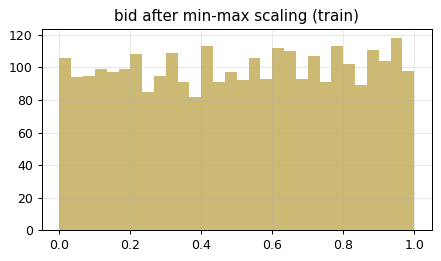

In [7]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler().fit(train[["bid"]])
mtr = mm.transform(train[["bid"]]).ravel()
print("range:", round(mtr.min(),3), "to", round(mtr.max(),3))

plt.figure(figsize=(5,3))
plt.hist(mtr, bins=30, color=GOLD); plt.title("bid after min-max scaling (train)"); plt.show()

## 7 · Robust scaling — *numeric with outliers*

Center by the **median**, scale by the **IQR** — outliers barely move it.
**Use when** the feature has heavy tails / extreme values (`spend`).

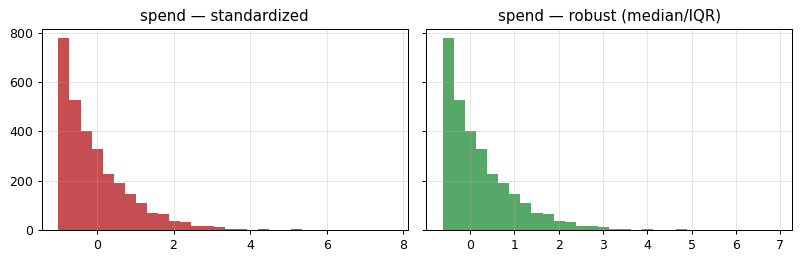

In [8]:
from sklearn.preprocessing import StandardScaler, RobustScaler

std = StandardScaler().fit(train[["spend"]]).transform(train[["spend"]]).ravel()
rob = RobustScaler().fit(train[["spend"]]).transform(train[["spend"]]).ravel()

fig, ax = plt.subplots(1, 2, figsize=(9,3), sharey=True)
ax[0].hist(std, bins=30, color=RED);   ax[0].set_title("spend — standardized")
ax[1].hist(rob, bins=30, color=GREEN); ax[1].set_title("spend — robust (median/IQR)")
plt.show()

## 8 · Log transform for skew — *heavy-tailed float*

`log1p(x)=log(1+x)` compresses a long right tail so a few giant campaigns don't
dominate. **Use for** spend, counts, engagement. **Gotcha:** needs `x >= 0`
(use `log1p`, or Yeo-Johnson in #13 for negatives).

skew before: 2.0  after: -0.53


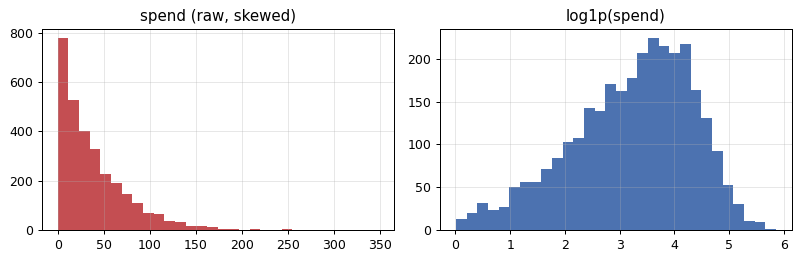

In [9]:
log_spend = np.log1p(train["spend"])
print("skew before:", round(train.spend.skew(),2), " after:", round(log_spend.skew(),2))

fig, ax = plt.subplots(1, 2, figsize=(9,3))
ax[0].hist(train.spend, bins=30, color=RED);  ax[0].set_title("spend (raw, skewed)")
ax[1].hist(log_spend, bins=30, color=BLUE);   ax[1].set_title("log1p(spend)")
plt.show()

## 9 · Missing values: impute **and** flag — *numeric*

Fill the gap (median) **and** add a `*_missing` indicator, because "it was missing"
is often signal. **Gotcha:** compute the median on **train** only.

median used: 30.41 | % missing in valid: 0.141


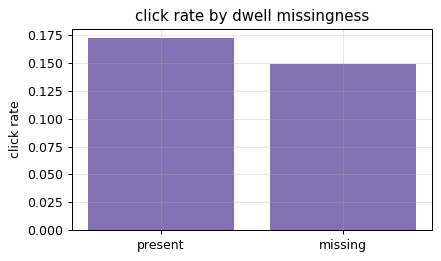

In [10]:
from sklearn.impute import SimpleImputer

med = SimpleImputer(strategy="median").fit(train[["dwell_secs"]])   # train median
dwell_missing = valid["dwell_secs"].isna().astype(int).to_numpy()
print("median used:", round(med.statistics_[0],2),
      "| % missing in valid:", round(dwell_missing.mean(),3))

rate_missing = valid.loc[dwell_missing==1, "clicked"].mean()
rate_present = valid.loc[dwell_missing==0, "clicked"].mean()
plt.figure(figsize=(5,3))
plt.bar(["present","missing"], [rate_present, rate_missing], color=PURPLE)
plt.title("click rate by dwell missingness"); plt.ylabel("click rate"); plt.show()

## 10 · Binning / discretization — *numeric → buckets*

Cut a continuous feature into quantile buckets (bid quartiles). **Use when** you
want monotonic, robust buckets or to let a linear model capture non-linearity.

quartile edges: [ 0.5   3.42  6.39  9.23 11.99]


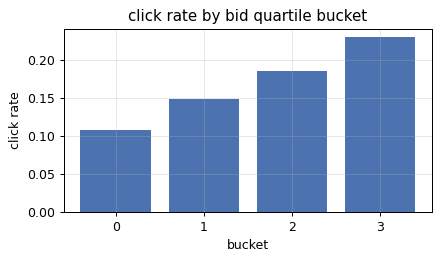

In [11]:
from sklearn.preprocessing import KBinsDiscretizer

kb = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile", subsample=None)
train_bins = kb.fit_transform(train[["bid"]]).ravel().astype(int)
print("quartile edges:", np.round(kb.bin_edges_[0], 2))

rate = pd.Series(train.clicked.to_numpy()).groupby(train_bins).mean()
plt.figure(figsize=(5,3))
plt.bar(rate.index.astype(str), rate.values, color=BLUE)
plt.title("click rate by bid quartile bucket"); plt.xlabel("bucket"); plt.ylabel("click rate"); plt.show()

---
# Easy (5) — combine steps & transforms

## 11 · Target (mean) encoding — and why the naive version **leaks**

Replace `campaign_id` with its mean click rate: powerful for high-cardinality IDs,
but the **naive** version uses each row's own label → the score "knows the answer".
Here we *reproduce* the leak; #16 fixes it with out-of-fold + smoothing.

rare-campaign encodings (0/1 = memorized label):
    campaign_id  clicked   camp_te
5          1060        0  0.000000
8          1387        1  0.666667
11         1204        0  0.000000
22         1200        0  0.333333
38         1746        0  0.500000


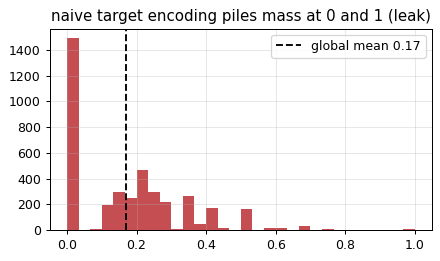

In [12]:
global_mean = df.clicked.mean()
leaky_map = df.groupby("campaign_id").clicked.mean()          # uses every row's label
df_leaky = df.assign(camp_te=df.campaign_id.map(leaky_map))

counts = df.campaign_id.value_counts()
rare = counts[counts <= 3].index
print("rare-campaign encodings (0/1 = memorized label):")
print(df_leaky[df_leaky.campaign_id.isin(rare)][["campaign_id","clicked","camp_te"]].head())

plt.figure(figsize=(5,3))
plt.hist(df_leaky.camp_te, bins=30, color=RED)
plt.axvline(global_mean, color="k", ls="--", label=f"global mean {global_mean:.2f}")
plt.title("naive target encoding piles mass at 0 and 1 (leak)"); plt.legend(); plt.show()

## 12 · ColumnTransformer — numeric + categorical in one pass

Real datasets mix types. `ColumnTransformer` applies the right transform to each
column group and produces one matrix — and (crucially) `fit`s on train only.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num = ["bid", "spend"]
cat = ["device", "member_country", "creative_size"]
pre = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat),
])
Xtr = pre.fit_transform(train)          # fit on train
Xva = pre.transform(valid)              # apply to valid
print("train matrix:", Xtr.shape, "| valid matrix:", Xva.shape)
print("numeric cols:", len(num), "| one-hot cols:", Xtr.shape[1]-len(num))

train matrix: (3000, 18) | valid matrix: (1000, 18)
numeric cols: 2 | one-hot cols: 16


## 13 · PowerTransformer (Yeo-Johnson) — *make a float ~Gaussian*

Learns the best power transform to reduce skew; Yeo-Johnson also handles zeros /
negatives (Box-Cox needs strictly positive). **Use when** a model assumes roughly
normal inputs.

skew: 2.0 -> -0.04 | lambda: 0.201


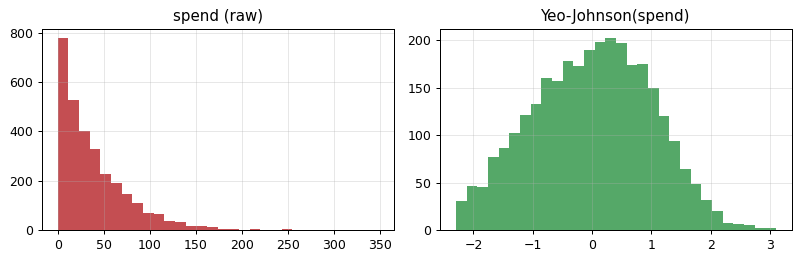

In [14]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson").fit(train[["spend"]])
yj = pt.transform(train[["spend"]]).ravel()
print("skew:", round(train.spend.skew(),2), "->", round(pd.Series(yj).skew(),2),
      "| lambda:", round(pt.lambdas_[0],3))

fig, ax = plt.subplots(1, 2, figsize=(9,3))
ax[0].hist(train.spend, bins=30, color=RED);  ax[0].set_title("spend (raw)")
ax[1].hist(yj, bins=30, color=GREEN);         ax[1].set_title("Yeo-Johnson(spend)")
plt.show()

## 14 · QuantileTransformer — *rank-based normalization*

Maps any distribution onto a uniform or normal one by rank: extremely robust to
outliers. **Gotcha:** non-linear, can wash out fine structure; fit on train.

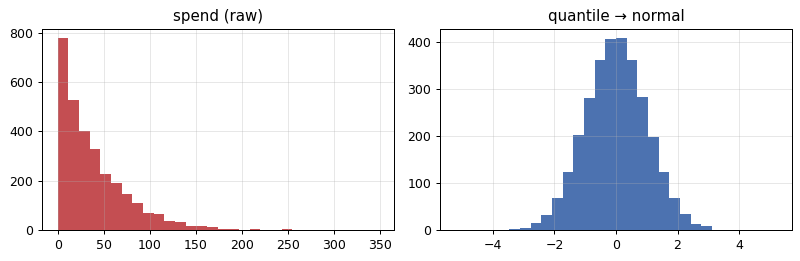

In [15]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(output_distribution="normal", n_quantiles=500, random_state=0)
qs = qt.fit_transform(train[["spend"]]).ravel()

fig, ax = plt.subplots(1, 2, figsize=(9,3))
ax[0].hist(train.spend, bins=30, color=RED);  ax[0].set_title("spend (raw)")
ax[1].hist(qs, bins=30, color=BLUE);          ax[1].set_title("quantile → normal")
plt.show()

## 15 · Winsorizing / clipping outliers — *cap extremes*

Clip a feature to the 1st–99th percentile learned on train, so a few extreme
campaigns can't dominate a scaler or a linear weight.

clip to [0.4, 182.9] | valid max 311.1 -> 182.9


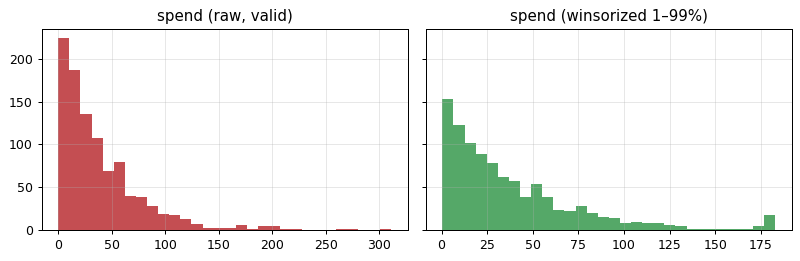

In [16]:
lo, hi = np.percentile(train.spend, [1, 99])       # thresholds from train
clipped = valid.spend.clip(lo, hi)
print(f"clip to [{lo:.1f}, {hi:.1f}] | valid max {valid.spend.max():.1f} -> {clipped.max():.1f}")

fig, ax = plt.subplots(1, 2, figsize=(9,3), sharey=True)
ax[0].hist(valid.spend, bins=30, color=RED);  ax[0].set_title("spend (raw, valid)")
ax[1].hist(clipped, bins=30, color=GREEN);    ax[1].set_title("spend (winsorized 1–99%)")
plt.show()

---
# Advanced (5) — leakage-safe & at scale

## 16 · Leakage-safe target encoding (out-of-fold + smoothing)

The right way to do #11: encode each training row using folds that **exclude it**,
and **shrink** rare campaigns toward the global mean:
$\hat{y}_c=\dfrac{n_c\bar{y}_c+m\bar{y}}{n_c+m}$. We compare the honest out-of-fold
AUC to the inflated in-fold AUC to *see* the leak disappear.

in-fold (leaky) AUC:  0.849
out-of-fold  AUC:     0.528


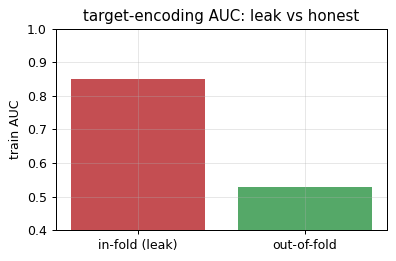

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def smoothed_map(frame, m=20):
    g = frame.groupby("campaign_id").clicked
    gm = frame.clicked.mean()
    return (g.count()*g.mean() + m*gm) / (g.count() + m), gm

tr = train.reset_index(drop=True)

# leaky in-fold encoding on the whole training set
enc_map, gm = smoothed_map(tr)
leak = tr.campaign_id.map(enc_map).fillna(gm).to_numpy().reshape(-1,1)
auc_leak = roc_auc_score(tr.clicked,
            LogisticRegression().fit(leak, tr.clicked).predict_proba(leak)[:,1])

# honest out-of-fold encoding
oof = np.zeros(len(tr))
for fit_idx, enc_idx in StratifiedKFold(5, shuffle=True, random_state=0).split(tr, tr.clicked):
    m_map, g = smoothed_map(tr.iloc[fit_idx])
    oof[enc_idx] = tr.iloc[enc_idx].campaign_id.map(m_map).fillna(g).to_numpy()
auc_oof = roc_auc_score(tr.clicked,
            LogisticRegression().fit(oof.reshape(-1,1), tr.clicked).predict_proba(oof.reshape(-1,1))[:,1])

print(f"in-fold (leaky) AUC:  {auc_leak:.3f}")
print(f"out-of-fold  AUC:     {auc_oof:.3f}")
plt.figure(figsize=(4.5,3))
plt.bar(["in-fold (leak)","out-of-fold"], [auc_leak, auc_oof], color=[RED, GREEN])
plt.ylim(0.4, 1.0); plt.ylabel("train AUC")
plt.title("target-encoding AUC: leak vs honest"); plt.show()

## 17 · Feature hashing — *very high cardinality, fixed width*

Hash `campaign_id` into a fixed number of buckets: constant memory, no vocabulary,
handles unseen ids. **Gotcha:** collisions (two ids share a bucket) — bound them by
choosing enough buckets.

  64 buckets -> 64 used for 793 distinct ids
 256 buckets -> 198 used for 793 distinct ids
1024 buckets -> 320 used for 793 distinct ids


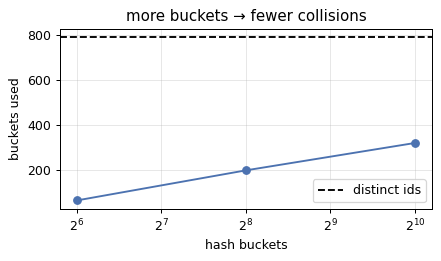

In [18]:
from sklearn.feature_extraction import FeatureHasher

sizes_ = [64, 256, 1024]; used_ = []
for nf in sizes_:
    fh = FeatureHasher(n_features=nf, input_type="string")
    b = np.asarray(fh.transform([[str(c)] for c in df.campaign_id]).argmax(axis=1)).ravel()
    u = len(np.unique(b)); used_.append(u)
    print(f"{nf:>4} buckets -> {u} used for {df.campaign_id.nunique()} distinct ids")

plt.figure(figsize=(5,3))
plt.plot(sizes_, used_, marker="o", color=BLUE)
plt.axhline(df.campaign_id.nunique(), ls="--", color="k", label="distinct ids")
plt.xscale("log", base=2); plt.xlabel("hash buckets"); plt.ylabel("buckets used")
plt.title("more buckets → fewer collisions"); plt.legend(); plt.show()

## 18 · Entity embeddings — a dense vector per id

A learned **dense** vector beats one-hot for high-cardinality ids. Deep models use
`torch.nn.Embedding`; here we build a runnable stand-in with **truncated SVD** of a
campaign × context matrix, giving each campaign a 2-D coordinate we can plot and
color by click rate. Similar campaigns land near each other.

embedding shape (n_campaigns, dim): (793, 2)


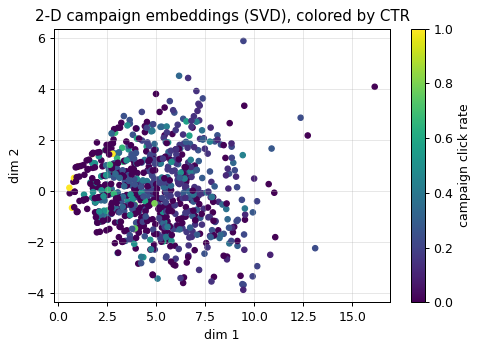

In [19]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder

ctx = OneHotEncoder(sparse_output=False).fit_transform(
        df[["member_country","device","creative_size"]])
camp_codes, camp_uniques = pd.factorize(df.campaign_id)
agg = np.zeros((len(camp_uniques), ctx.shape[1]))
np.add.at(agg, camp_codes, ctx)                       # sum context rows per campaign
emb = TruncatedSVD(n_components=2, random_state=0).fit_transform(agg)

camp_ctr = df.groupby("campaign_id").clicked.mean().reindex(camp_uniques).to_numpy()
plt.figure(figsize=(5.5,4))
sc = plt.scatter(emb[:,0], emb[:,1], c=camp_ctr, cmap="viridis", s=18)
plt.colorbar(sc, label="campaign click rate")
plt.title("2-D campaign embeddings (SVD), colored by CTR")
plt.xlabel("dim 1"); plt.ylabel("dim 2"); plt.show()
print("embedding shape (n_campaigns, dim):", emb.shape)

## 19 · A full leakage-safe pipeline (fit on train, score on valid)

Wire preprocessing + model into one `Pipeline`. Because it `fit`s only on train,
validation never touches any statistic — the AUC you get is the one production sees.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

num = ["bid","spend","dwell_secs"]; cat = ["device","member_country","creative_size"]
pre = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat),
])
clf = Pipeline([("pre", pre), ("model", LogisticRegression(max_iter=1000))])
clf.fit(train, train.clicked)                              # fit on train ONLY
auc = roc_auc_score(valid.clicked, clf.predict_proba(valid)[:,1])
print(f"honest valid AUC (fit on train only): {auc:.3f}")
print("→ this is the number that will match production.")

honest valid AUC (fit on train only): 0.648
→ this is the number that will match production.


## 20 · Encoder bake-off — same model, four encodings of `campaign_id`

Which categorical encoder should you use for a high-cardinality id? Encode it four
ways, train the **same** logistic model, and compare honest valid AUC **and** the
number of columns each produces.

              valid_AUC  n_cols
one-hot           0.591   780.0
frequency         0.624     3.0
target (OOF)      0.624     3.0
hashing(64)       0.595    66.0


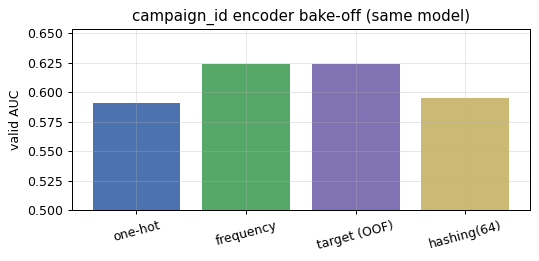

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction import FeatureHasher
from sklearn.model_selection import StratifiedKFold

y_tr, y_va = train.clicked.to_numpy(), valid.clicked.to_numpy()
base_tr = train[["bid","spend"]].fillna(0).to_numpy()
base_va = valid[["bid","spend"]].fillna(0).to_numpy()

def auc_with(extra_tr, extra_va):
    Xtr = np.hstack([base_tr, extra_tr]); Xva = np.hstack([base_va, extra_va])
    m = LogisticRegression(max_iter=1000).fit(Xtr, y_tr)
    return roc_auc_score(y_va, m.predict_proba(Xva)[:,1]), Xtr.shape[1]

results = {}
oh = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(train[["campaign_id"]])
results["one-hot"] = auc_with(oh.transform(train[["campaign_id"]]), oh.transform(valid[["campaign_id"]]))
fr = train.campaign_id.value_counts(normalize=True)
results["frequency"] = auc_with(train.campaign_id.map(fr).fillna(0).to_numpy().reshape(-1,1),
                                valid.campaign_id.map(fr).fillna(0).to_numpy().reshape(-1,1))
def oof_te(m=20):
    t = train.reset_index(drop=True); oof = np.zeros(len(t))
    for fit_idx, enc_idx in StratifiedKFold(5, shuffle=True, random_state=0).split(t, t.clicked):
        f = t.iloc[fit_idx]; g = f.groupby("campaign_id").clicked; gm = f.clicked.mean()
        mp = (g.count()*g.mean() + m*gm)/(g.count()+m)
        oof[enc_idx] = t.iloc[enc_idx].campaign_id.map(mp).fillna(gm).to_numpy()
    full = train.groupby("campaign_id").clicked; gm = train.clicked.mean()
    fmap = (full.count()*full.mean()+m*gm)/(full.count()+m)
    return oof.reshape(-1,1), valid.campaign_id.map(fmap).fillna(gm).to_numpy().reshape(-1,1)
results["target (OOF)"] = auc_with(*oof_te())
fh = FeatureHasher(n_features=64, input_type="string")
htr = fh.transform([[str(c)] for c in train.campaign_id]).toarray()
hva = fh.transform([[str(c)] for c in valid.campaign_id]).toarray()
results["hashing(64)"] = auc_with(htr, hva)

tbl = pd.DataFrame({k: {"valid_AUC": round(v[0],3), "n_cols": v[1]} for k,v in results.items()}).T
print(tbl)
plt.figure(figsize=(6,3))
plt.bar(list(tbl.index), tbl.valid_AUC.to_numpy(), color=[BLUE, GREEN, PURPLE, GOLD])
plt.ylim(0.5, float(tbl.valid_AUC.max())+0.03); plt.ylabel("valid AUC")
plt.title("campaign_id encoder bake-off (same model)"); plt.xticks(rotation=15); plt.show()

---
## Recap — the practical checklist

- **Categorical:** one-hot (low card., nominal) · ordinal (real order) · frequency
  (medium) · target-encoding **out-of-fold + smoothed** (high card., strong signal)
  · hashing / embeddings (very high card.). Never integer-code a nominal feature.
- **Numeric / float:** standardize / min-max / robust-scale (match the model & the
  outliers) · `log1p` / Yeo-Johnson / quantile for skew · winsorize extremes ·
  impute **and** add a missingness flag.
- **The rule that prevents leakage:** `fit` every transform on the **train split
  only**, then `transform` valid / serving — ideally inside a `Pipeline` /
  `ColumnTransformer` so it's impossible to forget.